## 1. Problem Statement

The objective of this project is to predict whether a person is diabetic or not using medical features such as Glucose, Blood Pressure, Skin Thickness, Insulin, BMI, Diabetes Pedigree Function, Age, and Pregnancies.  
The dataset contains missing values and outliers which need to be handled before training reliable machine learning models.

---

## 2. Approach

1. **Data Cleaning**  
   - Replaced invalid zero values in medical features with `NaN`.  
   - Handled missing values using `SimpleImputer` with mean and median strategies.

2. **Train-Test Split**  
   - Performed stratified train-test split to preserve class distribution.

3. **Outlier Handling and Scaling**  
   - Detected and handled outliers in highly skewed features.  
   - Applied feature scaling for comparative experiments, although tree-based models are robust to scaling.

4. **Model Training**  
   - Trained both Decision Tree and Random Forest classifiers.

5. **Model Evaluation**  
   - Evaluated models using Accuracy and F1-score metrics.

6. **Model Comparison**  
   - Compared performance of Decision Tree and Random Forest.  
   - Random Forest achieved better generalization due to ensemble learning and robustness to noise.

---

This approach ensures a robust and leakage-free machine learning pipeline with improved predictive performance.


# 1.Load diabetes.csv dataset

In [44]:
import pandas as pd
import numpy as np
df=pd.read_csv("/content/datasets/diabetes.csv")
df.shape

(768, 9)

In [2]:
df.head(5)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [4]:
print("# of Rows, # of Columns: ",df.shape)
print("\nColumn Name              % Null Values\n")
print(((df[:] == 0).sum())/768*100)

# of Rows, # of Columns:  (768, 9)

Column Name              % Null Values

Pregnancies                 14.453125
Glucose                      0.651042
BloodPressure                4.557292
SkinThickness               29.557292
Insulin                     48.697917
BMI                          1.432292
DiabetesPedigreeFunction     0.000000
Age                          0.000000
Outcome                     65.104167
dtype: float64


In [5]:
import numpy as np
invalid_zero_cols=["Glucose","BloodPressure","SkinThickness","Insulin","BMI"]
df[invalid_zero_cols]=df[invalid_zero_cols].replace(0,np.nan)

In [6]:
print("\ncolumns     %null values\n")
print(((df[:]==0).sum())/768*100)


columns     %null values

Pregnancies                 14.453125
Glucose                      0.000000
BloodPressure                0.000000
SkinThickness                0.000000
Insulin                      0.000000
BMI                          0.000000
DiabetesPedigreeFunction     0.000000
Age                          0.000000
Outcome                     65.104167
dtype: float64


In [7]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [8]:
df.describe().mean()

,0
Pregnancies,100.276829
Glucose,189.402800
BloodPressure,147.473418
SkinThickness,96.703800
Insulin,239.946760
BMI,122.260307
DiabetesPedigreeFunction,96.567963
Age,126.125140
Outcome,96.353239


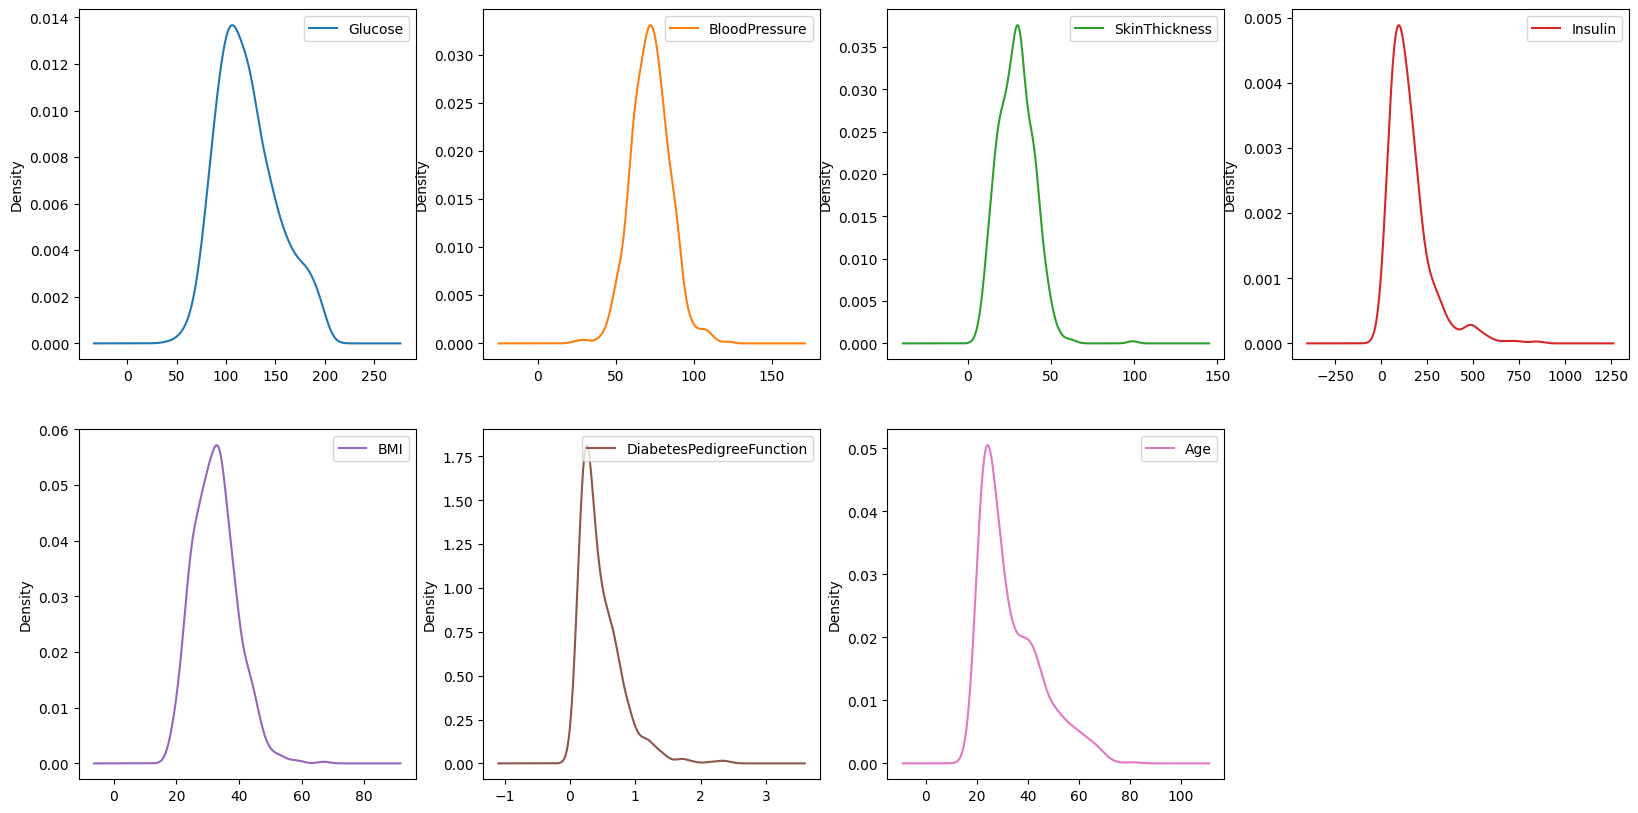

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
columns=["Glucose","BloodPressure","SkinThickness","Insulin","BMI","DiabetesPedigreeFunction","Age"]
df[columns].plot(kind='kde', subplots=True, layout=(2,4), figsize=(20,10), sharex=False)
plt.show()




<Axes: >

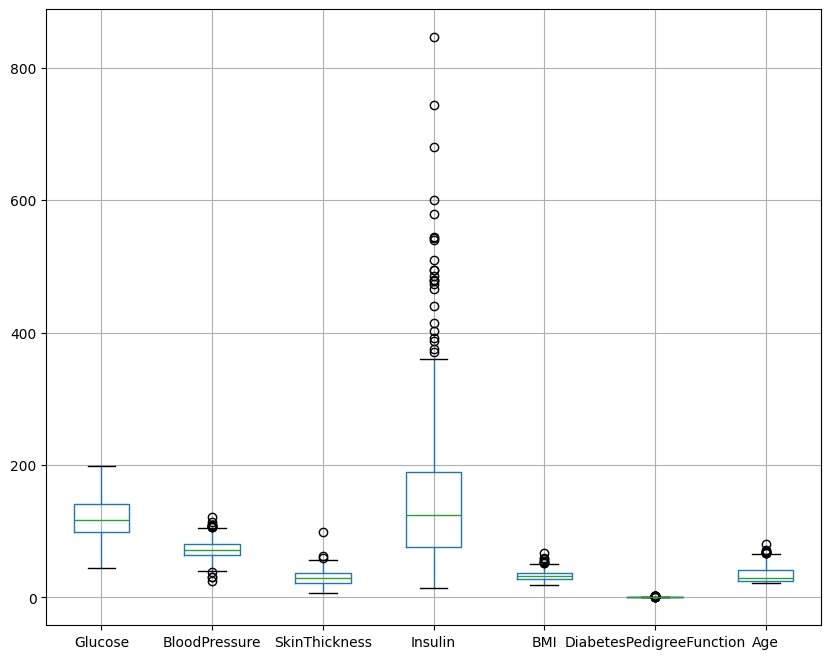

In [10]:
df[["Glucose","BloodPressure","SkinThickness","Insulin","BMI","DiabetesPedigreeFunction","Age"]].boxplot(figsize=(10,8))

In [11]:
X=df.drop("Outcome",axis=1)
y=df["Outcome"]

In [12]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [13]:
X_train.shape

(614, 8)

In [14]:
X_test.shape

(154, 8)

In [15]:
columns=["Glucose","BloodPressure","SkinThickness","Insulin","BMI","DiabetesPedigreeFunction","Age"]
df.before=df.copy()

/tmp/ipython-input-3168796911.py:2: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df.before=df.copy()


# 2.Applied Simpleimputer

In [16]:
from sklearn.impute import SimpleImputer
mean_imputer   = SimpleImputer(strategy="mean")
median_imputer = SimpleImputer(strategy="median")
X_train_mean   = X_train.copy()
X_test_mean    = X_test.copy()
X_train_median = X_train.copy()
X_test_median  = X_test.copy()
# Mean
X_train_mean[columns] = mean_imputer.fit_transform(X_train[columns])
X_test_mean[columns]  = mean_imputer.transform(X_test[columns])
# Median
X_train_median[columns] = median_imputer.fit_transform(X_train[columns])
X_test_median[columns]  = median_imputer.transform(X_test[columns])


In [27]:
X_train_mean.isnull().sum()
X_train_median.isnull().sum()
X_test_mean.isnull().sum()
X_test_median.isnull().sum()


,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0


In [ ]:
Before and after(distribution) simpleimputer

# Before and after(distribution) Applied Simpleimputer

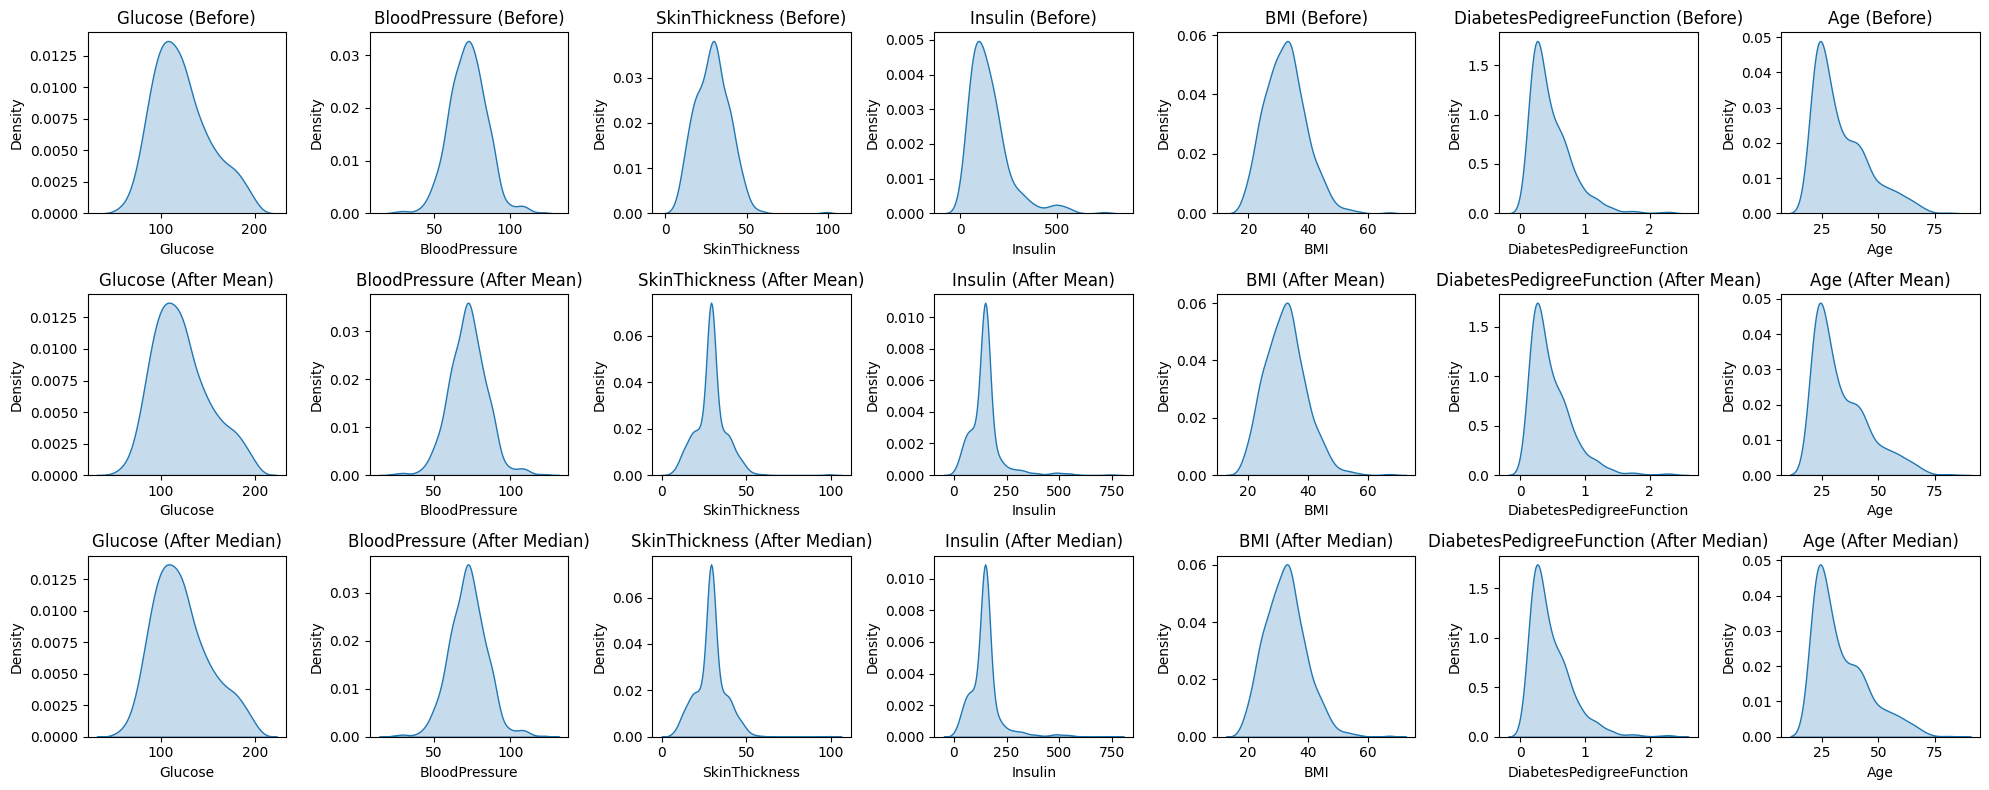

In [17]:
fig, axes = plt.subplots(3, len(columns), figsize=(20, 8))
for i, col in enumerate(columns):
    sns.kdeplot(X_train[col], ax=axes[0, i], fill=True)
    axes[0, i].set_title(col + " (Before)")

    sns.kdeplot(X_train_mean[col], ax=axes[1, i], fill=True)
    axes[1, i].set_title(col + " (After Mean)")

    sns.kdeplot(X_train_mean[col], ax=axes[2, i], fill=True)
    axes[2, i].set_title(col + " (After Median)")

plt.tight_layout()
plt.show()


In [28]:
X_train.isnull().sum()

,0
Pregnancies,0
Glucose,4
BloodPressure,23
SkinThickness,175
Insulin,290
BMI,9
DiabetesPedigreeFunction,0
Age,0


In [29]:
X_train_mean.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0


In [32]:
X_train_median.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0


In [31]:
X_test.isnull().sum()

,0
Pregnancies,0
Glucose,1
BloodPressure,12
SkinThickness,52
Insulin,84
BMI,2
DiabetesPedigreeFunction,0
Age,0


In [35]:
for col in columns:
    diff = (X_test[col] != X_test_mean[col]).sum()
    print(col, "changed in test:", diff)


Glucose changed in test: 1
BloodPressure changed in test: 12
SkinThickness changed in test: 52
Insulin changed in test: 84
BMI changed in test: 2
DiabetesPedigreeFunction changed in test: 0
Age changed in test: 0


In [26]:
X_test_mean.isnull().sum()


,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0


# Preprocessing Summary

| Step | What I Did |
|------|------------|
| Missing values | Converted invalid 0 → NaN |
| Imputation | Mean & Median (SimpleImputer) |
| Train-Test Split | Stratified split |
| Outliers | Not handled |
| Scaling | Not applied |
| Models | Decision Tree, Random Forest |

# Model train
1.Decision tree
2.Random Forest

In [36]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,f1_score
model_dt=DecisionTreeClassifier(random_state=42)
model_dt.fit(X_train_mean,y_train)
y_pred=model_dt.predict(X_test_mean)
print("accuracy acore:",accuracy_score(y_test,y_pred))
print("f1_score:",f1_score(y_test,y_pred))

accuracy acore: 0.6688311688311688
f1_score: 0.48484848484848486


In [37]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,f1_score
model_dt=DecisionTreeClassifier(random_state=42)
model_dt.fit(X_train_median,y_train)
y_pred=model_dt.predict(X_test_median)
print("accuracy acore:",accuracy_score(y_test,y_pred))
print("f1_score:",f1_score(y_test,y_pred))

accuracy acore: 0.6818181818181818
f1_score: 0.5148514851485149


In [42]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,f1_score
model_rf=RandomForestClassifier(n_estimators=300,max_depth=8,random_state=42)
model_rf.fit(X_train_median,y_train)
y_pred_rf=model_dt.predict(X_test_median)
print("accuracy acore:",accuracy_score(y_test,y_pred_rf))
print("f1_score:",f1_score(y_test,y_pred_rf))


accuracy acore: 0.6818181818181818
f1_score: 0.5148514851485149


In [43]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,f1_score
model_rf=RandomForestClassifier(n_estimators=300,max_depth=8,random_state=42)
model_rf.fit(X_train_mean,y_train)
y_pred_rf=model_dt.predict(X_test_mean)
print("accuracy acore:",accuracy_score(y_test,y_pred_rf))
print("f1_score:",f1_score(y_test,y_pred_rf))

accuracy acore: 0.6883116883116883
f1_score: 0.5294117647058824
